# Satistical Baseline for Anomaly detection

 Basically checks for the dates when a rolling return, volatility, or volume caused the price of stock to go beyond it's normal (rolling mean) by ±3σ

## Importing libraries required for this, and the clean parquet data made for this model.

In [8]:
import pandas as pd
import numpy as np
from pathlib import Path

DATA_DIR = Path("../data")
features = pd.read_parquet(DATA_DIR / "features_clean.parquet")

print(features.shape)
features.head()


(1184191, 5)


ret_zscore     vol_5    vol_20    vol_60  vol_zscore
Date       Ticker                                                      
2015-03-31 A        -0.265168  0.010081  0.012667  0.014717   -0.410469
           AAPL     -0.938535  0.020079  0.014414  0.017461   -0.650943
           ABBV      0.313153  0.015404  0.019325  0.020973   -0.017244
           ABT      -1.348220  0.009937  0.011308  0.011799    0.387669
           ACGL     -2.030660  0.011328  0.009421  0.008541    2.016447

## Building detector that checks whether a value is ±3σ

In [9]:
features = features.copy()
features["stat_anomaly"] = features["ret_zscore"].abs() > 3

n_flagged = features["stat_anomaly"].sum()
total = len(features)
print(f"Flagged {n_flagged} of {total} stock-days ({100*n_flagged/total:.2f}%)")


Flagged 8298 of 1184191 stock-days (0.70%)


## 0.7% of anomalies detected in return z-score. Which is twice the amount normal distribution predicts (0.3%). 

## a quick look at what the baseline actually flagged, to build intuiition

In [10]:
flagged = features[features["stat_anomaly"]]
print("Flagged days by year:")
print(flagged.groupby(flagged.index.get_level_values("Date").year).size())

Flagged days by year:
Date
2015     556
2016    1003
2017    1084
2018    1013
2019     778
2020     785
2021     626
2022     501
2023     843
2024    1109
dtype: int64


## Something counter-intuitive occured, I assumed the most anomolous year would be 2020 given the COVID crash. 

### However, I realized that my model is build to check anomalies relative to it's recent 20 days. Deep into 2020, the recent normal was the high volatility in price. Which is why those didn't get flagged as much. Even with high volatility being normal, we still found 785 anomolous datas. That's the finding I'm more intruiged about. 

### My detector doesn't flag "big moves." It flags "moves that are big relative to the stock's own recent calm."

### In 2017 and 2024, in the calmer years, even the modest jolt can punch through the 3 s.d. barrier, causing more anomalies. 

## This is exactly why we need to consider all the features above. Because crashes hides so flawlessly inside a volatile regime, it's hard to consider it a crash at all after a while. It becomes the new normal. 

## Considering Isolation Forest that takes all the featues together to flag a ticker, or LSTM that considers all points over time sequence to check a temporal pattern outbreak will fill in the gap this model creates. 

## To ensure this is the case, I will check which exact dates have been flagged as anomalies in the year 2020. If my case is right, it should be near the ends of the year. 

In [11]:
flagged_2020 = flagged[flagged.index.get_level_values("Date").year == 2020]
print(flagged_2020.groupby(flagged_2020.index.get_level_values("Date").to_period("M")).size())

Date
2020-01    101
2020-02    122
2020-03    179
2020-04      1
2020-05     11
2020-06     56
2020-07     36
2020-08     37
2020-09     50
2020-10     55
2020-11    126
2020-12     11
Freq: M, dtype: int64


# The rolling ±3σ baseline systematically under-flags sustained volatility regimes (e.g., April 2020), concentrating detections at regime transitions rather than crisis peaks, because its rolling normalization absorbs sustained extremes into the recent baseline.

In [12]:
features.to_parquet(DATA_DIR / "detector1_statistical.parquet")
print("Saved detector 1 output:", features.shape, "| flagged:", features["stat_anomaly"].sum())

Saved detector 1 output: (1184191, 6) | flagged: 8298


## Visualizing the Statistical Baseline

The two charts below illustrate what the ±3σ detector flags and, more
importantly, what it *misses*. Together they reveal that this baseline
measures *novelty relative to recent behavior* rather than absolute magnitude —
a property that will matter when we compare it against the Isolation Forest
and LSTM detectors. graph the above results 

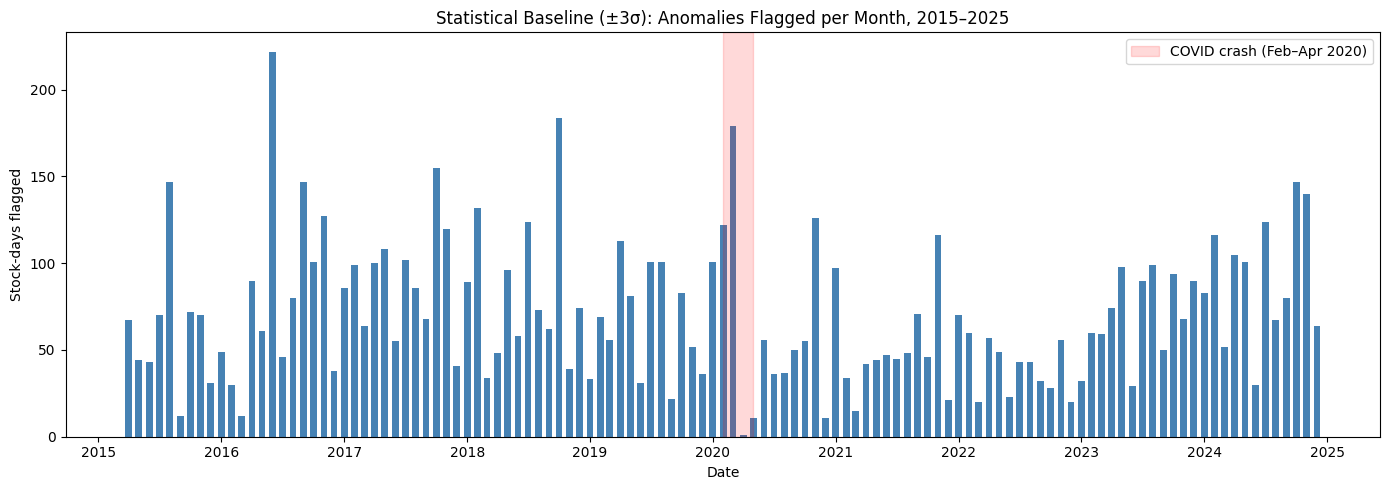

Saved chart to results/


In [13]:
import matplotlib.pyplot as plt

# monthly flag counts across the full period
monthly = flagged.groupby(
    flagged.index.get_level_values("Date").to_period("M")
).size()
monthly.index = monthly.index.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(monthly.index, monthly.values, width=20, color="steelblue")

# highlight the 2020 crash window
ax.axvspan(pd.Timestamp("2020-02-01"), pd.Timestamp("2020-04-30"),
           color="red", alpha=0.15, label="COVID crash (Feb–Apr 2020)")

ax.set_title("Statistical Baseline (±3σ): Anomalies Flagged per Month, 2015–2025")
ax.set_ylabel("Stock-days flagged")
ax.set_xlabel("Date")
ax.legend()
plt.tight_layout()
plt.show()

# at the end of the monthly-flags cell, after plt.show():
fig.savefig("../results/statistical_baseline_monthly.png", dpi=150, bbox_inches="tight")
print("Saved chart to results/")

### Statistical Baseline: Monthly Anomaly Counts (2015–2025)

This chart shows how many stock-days the ±3σ baseline flagged as anomalous in
each month across the full period. Each bar is one month; taller bars mean more
flagged days. The red band marks the COVID crash (Feb–Apr 2020).

**The key thing to notice is inside the red band.** Flagging *climbs* into the
crash — February and March 2020 are among the busier months — and then
**collapses in April**, which shows only a single flagged day despite April
being one of the most chaotic months in market history.

**Why?** The detector does not measure the *size* of a price move. It measures
how surprising a move is *relative to the stock's own recent behavior* (the
z-score divides by the trailing 20-day volatility). By April 2020, the market
had been violently volatile for weeks, so large daily swings had become the
"recent normal" — and the detector stopped seeing them as surprising. It fires
at the *onset* of the crash, when calm first breaks, then goes quiet once
turbulence becomes expected.

**Takeaway:** this baseline detects *regime changes and novelty*, not raw
magnitude. It systematically under-flags sustained crises. This is a known
limitation of rolling-window normalization — and it is exactly the kind of
event the other two detectors (which read volume and volatility levels
directly) may catch instead.

## Since I have been using apple for most of my data acquisition testing, I'll check the anomoly regions for AAPL ticker.

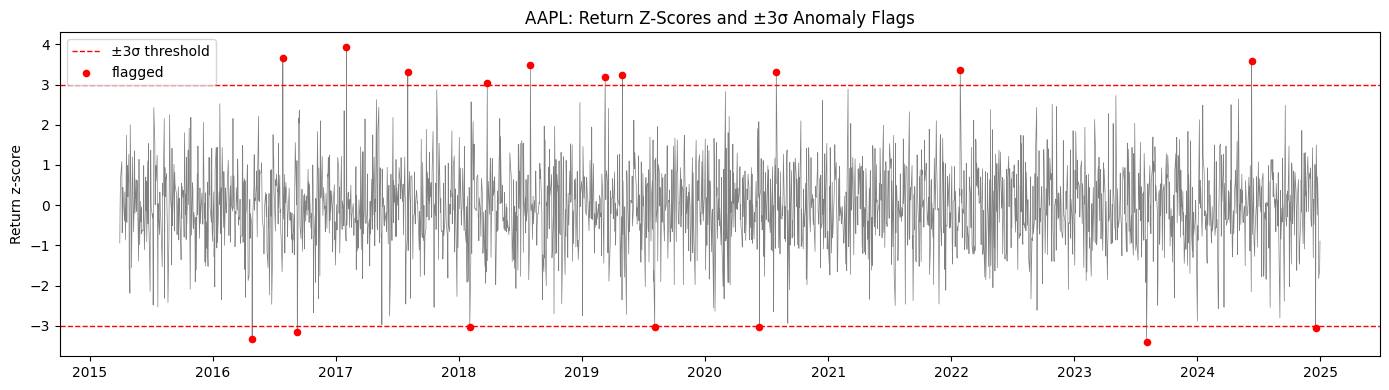

Saved chart to results/


In [14]:
aapl = features.xs("AAPL", level="Ticker")

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(aapl.index, aapl["ret_zscore"], linewidth=0.5, color="gray")
ax.axhline(3, color="red", linestyle="--", linewidth=1, label="±3σ threshold")
ax.axhline(-3, color="red", linestyle="--", linewidth=1)

# mark the flagged days
flagged_aapl = aapl[aapl["ret_zscore"].abs() > 3]
ax.scatter(flagged_aapl.index, flagged_aapl["ret_zscore"],
           color="red", s=20, zorder=5, label="flagged")

ax.set_title("AAPL: Return Z-Scores and ±3σ Anomaly Flags")
ax.set_ylabel("Return z-score")
ax.legend()
plt.tight_layout()
plt.show()

fig.savefig("../results/aapl_zscore_flags.png", dpi=150, bbox_inches="tight")
print("Saved chart to results/")

### How the Detector Works: AAPL Return Z-Scores

This chart shows the logic of the ±3σ rule for a single stock (AAPL). The gray
line is AAPL's daily return z-score — how many standard deviations each day's
return sits from its recent 20-day average. The dashed red lines mark the ±3σ
thresholds. Red dots are the days the detector flagged as anomalous.

**The gray band stays mostly between −3 and +3**, confirming that the vast
majority of trading days are ordinary — returns within a few standard deviations
of recent behavior. Only the handful of days that punch through the dashed lines
(the red dots) get flagged.

Note that the band's *width* is fairly stable over the whole decade. This is the
z-score doing its job: because it is measured relative to *recent* volatility,
it stays roughly standardized through calm and turbulent periods alike, rather
than drifting the way raw prices would. The flags are spread across the years
rather than clustered — consistent with the finding above that this detector
responds to local surprises, not to any single large market event.

In [15]:
features.to_parquet(DATA_DIR / "detector1_statistical.parquet")
print("Saved detector 1 output:", features.shape, "| flagged:", features["stat_anomaly"].sum())

Saved detector 1 output: (1184191, 6) | flagged: 8298
